# Binary classification on make_moons with the micrograd engine

This notebook applies the scalar autograd engine implemented in `micrograd/engine.py` to a non-trivial classification task: separating the two interlocking half-circles of `sklearn.datasets.make_moons`. The point of the demonstration is to show that the engine — built entirely from scalar `Value` objects and three primitive operators — is sufficient to train a real neural network on a real dataset and learn a curved decision boundary that no linear classifier can reproduce.

**Why make_moons specifically.** The dataset is the canonical visualizable benchmark for nonlinear binary classification. The two classes are not linearly separable, so a linear model (logistic regression, single-layer perceptron) is provably incapable of reaching high accuracy — meaning any success here is attributable to the network's nonlinearity, not to a linear shortcut. Two input dimensions also lets us plot the learned decision boundary directly, which is the most legible diagnostic for a small classifier.

The engine itself is not used here in any privileged way — every operation in this notebook is the same `Value` arithmetic that the gradient-check tests verify against PyTorch. If those tests pass and the notebook below trains successfully, the engine is correct.

In [1]:
import random

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

from micrograd.engine import Value
from micrograd.nn import MLP

# Seed every source of randomness for a reproducible run. The notebook will
# train to the same final loss and accuracy on every execution, and the
# decision boundary plot will be byte-identical across reruns.
random.seed(42)
np.random.seed(42)

%matplotlib inline

## Dataset

`make_moons(n_samples=100, noise=0.1)` produces 100 points arranged in two interlocking half-circles, one labeled 0 and one labeled 1. The `noise=0.1` parameter adds Gaussian jitter to each point's position — enough to introduce class overlap near the boundary (so the task is non-trivial and the model cannot achieve perfect accuracy by memorizing positions), but not so much that the moons fail to be visually distinct.

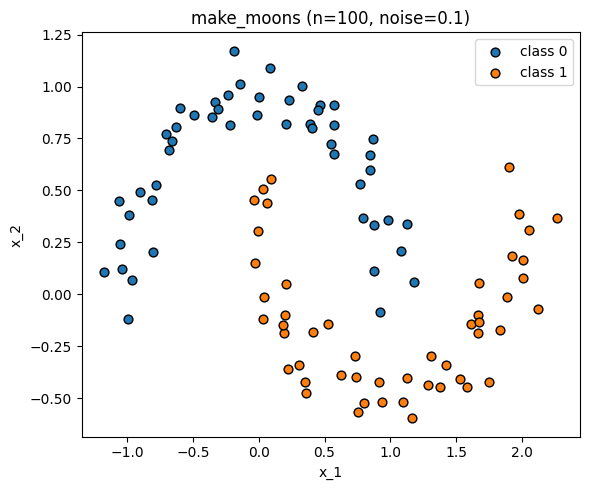

Class balance: 50 zeros, 50 ones


In [2]:
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='tab:blue', label='class 0', edgecolor='k', s=40)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='tab:orange', label='class 1', edgecolor='k', s=40)
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.title('make_moons (n=100, noise=0.1)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Class balance: {(y == 0).sum()} zeros, {(y == 1).sum()} ones")

## Preprocessing — feature normalization

Tanh saturates for large pre-activations: $|x| \gg 1 \Rightarrow \tanh(x) \approx \pm 1$, and the local gradient $1 - \tanh^2(x)$ collapses to zero. Once that happens, gradient signal through the affected unit dies and learning stalls — the vanishing-gradient regime.

Standardizing inputs to zero mean and unit variance keeps the initial linear combinations $\sum w_i x_i + b$ in the neighborhood of zero, which is exactly the steepest (highest-gradient) region of tanh. This makes the difference between a model that trains in 100 epochs and one that barely moves.

In [3]:
mu = X.mean(axis=0)
sigma = X.std(axis=0)
X_norm = (X - mu) / sigma

print(f"Before normalization: mean={X.mean(axis=0).round(3)}, std={X.std(axis=0).round(3)}")
print(f"After normalization:  mean={X_norm.mean(axis=0).round(3)}, std={X_norm.std(axis=0).round(3)}")

Before normalization: mean=[0.505 0.246], std=[0.888 0.495]
After normalization:  mean=[-0.  0.], std=[1. 1.]


## Architecture

`MLP(2, [16, 16, 1])` — two inputs (the normalized $x_1, x_2$ coordinates), two hidden layers of 16 tanh-activated neurons, one output neuron. This sizing is deliberate:

- **Two hidden layers** rather than one. A single hidden layer with enough width can approximate any continuous function (universal approximation), but in practice two narrow layers learn faster and more reliably than one wide layer for boundaries of this geometric complexity.
- **Width of 16** is comfortably above the minimum needed to fit the moon shape (which can be done with single-digit widths) but small enough that the 337-parameter network cannot memorize 100 points — there is no overfitting concern at this scale.
- **Single output neuron**, threshold at $p = 0.5$, treats the problem as binary classification with a Bernoulli output.

In [4]:
model = MLP(2, [16, 16, 1])
print(model)
print(f"Total parameters: {len(model.parameters())}")

Total parameters: 337


## Loss function — binary cross-entropy

The model output is a tanh-activated scalar in $(-1, 1)$. To interpret it as a probability we apply the sigmoid (logistic) function:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

This is equivalent to a 2-class softmax: sigmoid$(z)$ is exactly softmax$([0, z])[1]$. Sigmoid is the natural inverse-link for a Bernoulli output the same way softmax is for a categorical output.

The loss is **binary cross-entropy** — the negative log-likelihood of the Bernoulli distribution with parameter $p$:

$$L(y, p) = -\bigl[\, y \log p + (1 - y) \log(1 - p) \,\bigr]$$

When the true label is $y = 1$, only the first term contributes: $L = -\log p$, which is zero when $p = 1$ and grows without bound as $p \to 0$. Symmetrically for $y = 0$. This is the same negative log-likelihood objective the engine's `Value.log()` was added to support — BCE is just the two-class special case of softmax + NLL.

We implement BCE as a sum of `Value` operations directly. No `Loss` class, no `Module` — the engine sees this as one big composition of `+`, `*`, `**`, `exp`, and `log`, and recovers the correct gradient through every parameter via the standard backward pass.

In [5]:
def loss_fn(model, X, y):
    """Total binary cross-entropy loss over a dataset.

    For each sample (x_i, y_i):
        score_i = model(x_i)                            # tanh-activated output in (-1, 1)
        p_i     = 1 / (1 + exp(-score_i))               # sigmoid -> probability in (0, 1)
        L_i     = -[ y_i * log(p_i) + (1 - y_i) * log(1 - p_i) ]   # Bernoulli NLL

    Returned loss is the sum over the batch rather than the mean. The two
    are equivalent up to a constant rescaling, but the choice has a real
    consequence for the optimizer: gradient magnitude scales linearly with
    dataset size. The lr=0.01 below is tuned to n=100; scaling n up by 10x
    without rescaling lr would effectively 10x the step size and likely
    diverge. Sum is used here because it reads more directly as "total
    surprise across the batch"; production code typically uses mean to
    decouple lr from batch size.

    Built entirely from Value operations, so loss.backward() populates
    gradients on every model parameter automatically.
    """
    total = Value(0.0)
    for xi, yi in zip(X, y):
        score = model([Value(xi[0]), Value(xi[1])])
        p = (1 + (-score).exp()) ** -1            # sigmoid(score)
        term = yi * p.log() + (1 - yi) * (1 - p).log()
        total = total + (-term)
    return total

## Training loop

Standard full-batch gradient descent. 100 epochs, learning rate 0.01. Each epoch executes the four-step cycle that every neural network trainer reduces to:

1. **Forward pass** — evaluate the model on every input, accumulate the loss as a single `Value`.
2. **Zero gradients** — overwrite every parameter's `.grad` with 0.0 before backprop. Without this, gradients from previous epochs would compound (`+=` in the engine accumulates across calls), and the update direction would be wrong.
3. **Backward pass** — `loss.backward()` walks the computation graph from the loss node backward to every parameter, populating `.grad`.
4. **Update** — for each parameter, $\theta \leftarrow \theta - \eta \cdot \nabla_\theta L$.

The trained network is exactly the parameter list mutated in step 4.

In [6]:
epochs = 100
lr = 0.01
losses = []

for epoch in range(epochs):
    # 1. Forward pass — build the loss graph.
    loss = loss_fn(model, X_norm, y)

    # 2. Zero gradients on every parameter before the backward pass.
    for p in model.parameters():
        p.grad = 0.0

    # 3. Backward pass — populate gradients across the entire graph.
    loss.backward()

    # 4. Parameter update — vanilla SGD step.
    for p in model.parameters():
        p.data -= lr * p.grad

    losses.append(loss.data)

    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch:3d}  loss {loss.data:.4f}")

epoch   0  loss 55.4717


epoch  10  loss 40.9800


epoch  20  loss 39.0785


epoch  30  loss 37.6160


epoch  40  loss 36.3635


...

epoch  60  loss 32.4005


epoch  70  loss 32.1564


epoch  80  loss 32.0091


epoch  90  loss 31.9065


epoch  99  loss 31.8368


## Loss curve

A clean monotone descent confirms that the optimizer is moving the parameters in a direction that consistently reduces the objective. Bumps or plateaus would indicate a learning rate that is too large, a saturated nonlinearity, or a gradient bug.

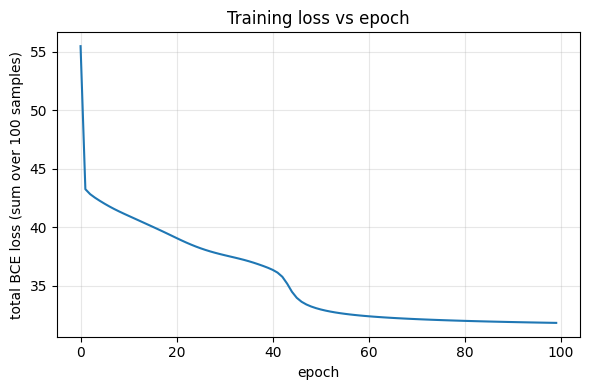

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(losses, color='tab:blue')
plt.xlabel('epoch')
plt.ylabel('total BCE loss (sum over 100 samples)')
plt.title('Training loss vs epoch')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluation

Training accuracy on the same 100 points used to fit the model. Because the network is small and the dataset has no held-out split, this is a sanity check rather than a generalization metric — it tells us whether the model fit at all, not whether it would generalize to fresh moons-distributed points. For a 337-parameter network on 100 samples with `noise=0.1`, near-perfect training accuracy is the expected outcome.

In [8]:
def predict(model, X):
    """Return predicted class (0 or 1) for each row of X by thresholding sigmoid output at 0.5."""
    preds = []
    for xi in X:
        score = model([Value(xi[0]), Value(xi[1])])
        p = (1 + (-score).exp()) ** -1
        preds.append(1 if p.data > 0.5 else 0)
    return np.array(preds)

y_pred = predict(model, X_norm)
accuracy = (y_pred == y).mean()
final_loss = losses[-1]
print(f"Final training loss: {final_loss:.4f}")
print(f"Training accuracy:   {accuracy:.4f}  ({(y_pred == y).sum()}/{len(y)} correct)")

Final training loss: 31.8368
Training accuracy:   1.0000  (100/100 correct)


## Decision boundary

A meshgrid sweeps over the input plane; the model classifies every grid point, and the predicted class colors the background. Training points are overlaid for context. The boundary between the two color regions is exactly the level set $\{x : p(x) = 0.5\}$ — the learned decision surface.

For a model with capacity to separate the moons, the boundary should curve between the two arcs, not slice through them as a straight line would. The figure is exported to `../assets/decision_boundary.png` and reused in the repository README.

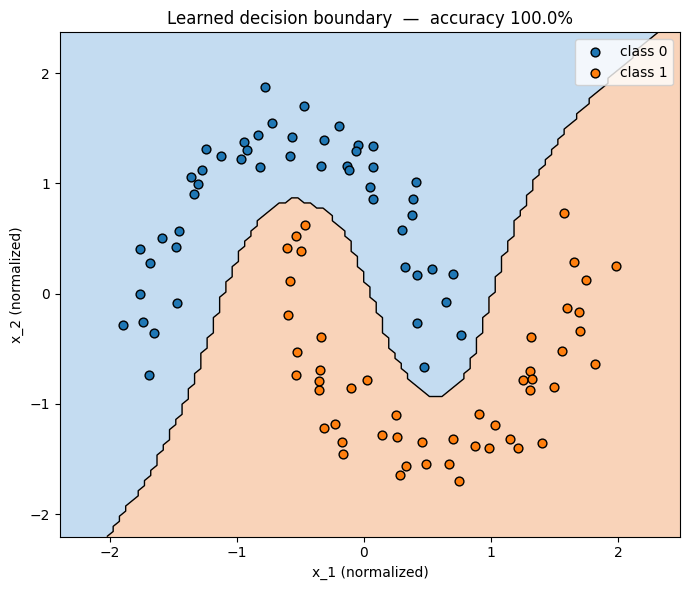

In [9]:
# Build the meshgrid in normalized feature space.
x_min, x_max = X_norm[:, 0].min() - 0.5, X_norm[:, 0].max() + 0.5
y_min, y_max = X_norm[:, 1].min() - 0.5, X_norm[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100),
)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Predict on the grid. This is the slow step — 10,000 forward passes through
# the Python-scalar engine. Takes a few seconds.
Z = predict(model, grid_points).reshape(xx.shape)

# Plot the decision regions and overlay training points.
fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=['#9ec5e8', '#f5b78b'], alpha=0.6)
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1.0)
ax.scatter(X_norm[y == 0, 0], X_norm[y == 0, 1], c='tab:blue', edgecolor='k', s=40, label='class 0')
ax.scatter(X_norm[y == 1, 0], X_norm[y == 1, 1], c='tab:orange', edgecolor='k', s=40, label='class 1')
ax.set_xlabel('x_1 (normalized)')
ax.set_ylabel('x_2 (normalized)')
ax.set_title(f'Learned decision boundary  —  accuracy {accuracy:.1%}')
ax.legend(loc='upper right')
plt.tight_layout()

plt.savefig('../assets/decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

This notebook trained an MLP, end to end, on a benchmark binary classification task using only the scalar autograd engine in `micrograd/engine.py`. The engine has no special-cased layer implementations, no batched operations, and no concept of "neural network" — it implements reverse-mode autodiff over scalar `Value` objects and three primitive operators. The `Neuron` / `Layer` / `MLP` classes in `micrograd/nn.py` compose those primitives into a network; the loss function and training loop compose them further. Everything that worked here is just the chain rule, executed in topological order.

The engine generalizes to anything expressible as a composition of differentiable scalar operations. The natural next step is sequence modeling — Karpathy's `makemore` lectures extend exactly this foundation to character-level language models, adding embedding tables, batch normalization, and eventually the Transformer.